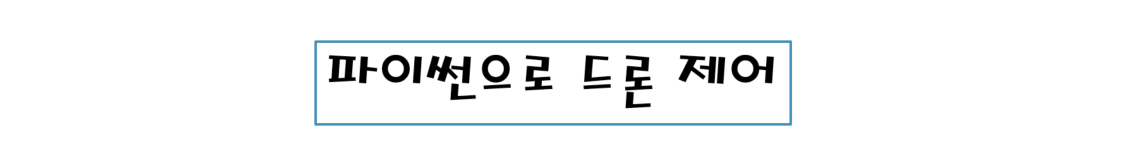

## ✅ 사전 준비

### 1. 필요 사항

* Python 3.x 설치 및 주피터랩 확인
  > py --list  
  > py -3.14 -m venv venv  
  > venv\Scripts\activate  
  > pip install jupyterlab
  > jupyter lab --port=10888
  > 
* Tello EDU 드론 준비 > 전원ON > 대기상태 확인 
* PC 또는 노트북이 **Tello EDU Wi-Fi**에 연결되어 있어야 함 (예: <font color=red><b>TELLO-SW##</b></font> )

### 2. 기본 통신 정보

<span style="display:inline-block;position:left;">

| 항목    | 값              |
| ----- | -------------- |
| 드론(서버) IP 주소 | `192.168.10.1` |
| 드론(서버) 포트 번호 | `8889` (UDP)   |

</span>

### <font color=red>드론과 노트북(태블릿) 연결이 완료</font>된 후 아래 코드를 실행하시오. 

In [ ]:
## ✅ 예제 코드: tello_basic.py
import socket
import time

# Tello 드론 정보
TELLO_IP = '192.168.10.1'
TELLO_PORT = 8889
TELLO_ADDRESS = (TELLO_IP, TELLO_PORT)

# 소켓 생성 및 바인딩
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
sock.bind(('0.0.0.0', 8890))  # 수신 포트 (로컬)

def send_command(command, delay=3):
    print(f"Sending command: {command}")
    sock.sendto(command.encode(), TELLO_ADDRESS)
    try:
        response, _ = sock.recvfrom(1024)
        print(f"Response: {response.decode()}")
    except socket.timeout:
        print("No response received.")
    time.sleep(delay)

# 드론 제어 시작 : 아래 주요 명령어 정리를 참조하여 명령어 재구성 : 4각비행, 5각비행, 별비행
send_command("command")    # SDK 모드 진입
send_command("takeoff")    # 이륙
send_command("cw 360")      # 시계 방향으로 90도 회전
send_command("land")       # 착륙

# 소켓 종료
sock.close()

## ✅ 주요 명령어 정리
<span style="display:inline-block;position:left;margin: 1px 1px 1px 20px;">

| 명령어          | 의미           |
| ------------ | ------------ |
| `command`    | SDK 모드 진입    |
| `takeoff`    | 이륙           |
| `land`       | 착륙           |
| `cw 90`      | 시계방향 90도 회전(1 ~ 360)  |
| `ccw 90`     | 반시계방향 90도 회전(1 ~ 360) |
| `forward 50` | 50cm 전진(20 ~ 500)      |
| `back 50`    | 50cm 후진(20 ~ 500)      |
| `up 30`      | 30cm 상승(20 ~ 500)      |
| `down 30`    | 30cm 하강(20 ~ 500)      |

</span>

<div style="background-color: skyblue; padding: 2px; border-radius: 1px;">
<h2><font color=red><b>[미션]</b></font> 위 명령어를 숙지하고, <b>tello_basic.py</b> 코드에  5각 비행 코드를 완성하라<br>(단, 비행거리는 30cm)</h2>
</div>

In [ ]:
# 미션 수행



<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;text-align:center;">
  <h1>API 활용하기</h1>
</div>

# DJI Drone 제공하는 API를 활용하기

## 사전준비사항
* API 모듈 추가
  > djitellopy 라이브러리 추가:  
  >  `pip install djitellopy`  
  > pip 업데이트:  
  >  `python -m pip install --upgrade pip`
  > 영상 라이브러리 추가:  
  >  `pip install opencv-python`
  > 
* <font color=red>[실습] 아래 기본 예시 코드를 실행하기</font>  

In [ ]:
## djitellopy 라이브러리 추가
!pip install djitellopy            

In [ ]:
## pip 업데이트
!python -m pip install --upgrade pip 

In [ ]:
## 영상 라이브러리 추가
!pip install opencv-python       

# 중요 자료
* <a href="Tello SDK 2.0 User Guide.pdf" target=_blank>Tello SDK 2.0 User Guide</a>
* <a href="https://djitellopy.readthedocs.io/en/latest/tello/">DJITellopy 매뉴얼 보기</a>
* <a href="https://github.com/damiafuentes/DJITelloPy">DJITellopy 파이썬코드 오픈 소스 보기</a>


## ✈️ 비행 제어 명령어

<span style="display:inline-block;position:left;">

| 메서드                                                   | 설명                                  |                                               |
| ----------------------------------------------------- | ----------------------------------- | --------------------------------------------- |
| `connect()`                                           | 드론과 연결                              |                                               |
| `takeoff()`                                           | 이륙                                  |                                               |
| `land()`                                              | 착륙                                  |                                               |
| `emergency()`                                         | 비상 정지 (모터 즉시 정지)                    |                                               |
| `move_up(x)` / `move_down(x)`                         | x(20 ~ 500 cm) 만큼 상승 / 하강                    |                                               |
| `move_left(x)` / `move_right(x)`                      | x(20 ~ 500 cm) 만큼 좌 / 우 이동                   |                                               |
| `move_forward(x)` / `move_back(x)`                    | x(20 ~ 500 cm) 만큼 전진 / 후진                    |                                               |
| `rotate_clockwise(x)` / `rotate_counter_clockwise(x)` | x(1 ~ 360 도) 만큼 시계 / 반시계 방향 회전              |                                               |
| `flip(direction)`                                     | 지정된 방향으로 플립 (예: 'l', 'r', 'f', 'b') |                                               |
| `go_xyz_speed(x, y, z, speed)`                        | 지정된 좌표로 이동 (cm 단위)<br> x,y,z : -500 ~ 500<br>speed: 10 ~ 100  |                                               |
| `curve_xyz_speed(...)`                                | 곡선 경로로 이동<br>x1,y1,z1,x2,y2,z2: -500 ~ 500<br>speed: 10 ~ 60 |                                               |
| `send_rc_control(lr, fb, ud, yaw)`                    | 실시간 RC 제어 (각 방향 속도 설정)              | 조이스틱 활용 |

</span>


<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  API활용 드론 비행(<font color=red>새로 배터리 교체시 필히 처음 한번 실행할 것</font>)
</div>

In [ ]:
# djitellopy 모듈 예시
from djitellopy import Tello
import time
tello = Tello(host='192.168.10.1')
tello.connect()
print(f"Bat : {tello.get_battery()}%")        
tello.takeoff()
tello.rotate_clockwise(360)
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
 드론 상태 정보
</div>

In [ ]:
print("■ 드론 상태정보")
print(f"드론상태: {tello.query_active()}")
print(f"Bat: {tello.get_battery()}%")
print(f"SDK버전: {tello.query_sdk_version()}")
print(f"제품번호(SD): {tello.query_serial_number()}")
print(f"현재 상태 dict: {tello.get_current_state()}")
print(f"bat(key) 상태: {tello.get_state_field('bat')}%")       

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 상태 정보
</div>

In [ ]:
print("■ 드론 비행 상태정보")
tello.takeoff()
print(f"Bat: {tello.get_battery()}%")
print(f"높이: {tello.get_height()}")
print(f"pitch,roll,yaw: {tello.query_attitude()}")                     
print(f"비행거리 tof: {tello.get_distance_tof()}")
print(f"비행시간 tof: {tello.get_flight_time()}")
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 : <font color=blue><b>이륙 후 높이를 측정하여 높이 만큼 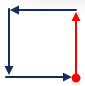상하앞뒤 사각 비행하기 코딩</b></font>
</div>

In [ ]:
tello.takeoff()
h = tello.get_height()
tello.move_up(h)
tello.move_forward(h)                                                                                                       
tello.move_down(h)
tello.move_back(h)
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 : <font color=blue><b>이륙 후 ⓐ 고도 150cm 높이로 비행 후  ⓑ 360도 회전 후 ⓒ 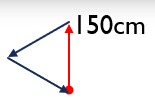 대각선 비행으로 이동 후 착륙하라</b></font>
</div>

In [ ]:
tello.takeoff()
h = tello.get_height()
d = 150 - h
half_d = int(d/2) # 정수값으로 변환                                                                                   
tello.move_up(d)
tello.rotate_counter_clockwise(360)
tello.go_xyz_speed(d,0,-half_d, 30)
tello.go_xyz_speed(-d,0,-half_d, 30)
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 : <font color=blue><b>이륙 후 ⓐ 고도 120cm 높이에서 ⓑ 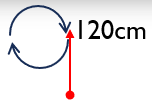 곡선비행 후 착륙하라</b></font>
</div>

In [ ]:
tello.takeoff()
h = tello.get_height()
d = 120 - h
tello.move_up(d)
tello.curve_xyz_speed(50,0,-60,100,0,0,30)                                                                     
tello.curve_xyz_speed(-50,0,60,-100,0,0,30)
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 비행 : <font color=blue><b>이륙 후 ⓐ 고도 120cm 높이에서 ⓑ 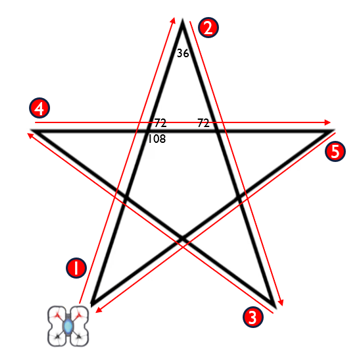별모양 비행(지름: 50cm) 후 착륙하라</b></font>
</div>

In [ ]:
tello.takeoff()
h = tello.get_height()
d = 120 - h
f = 50
angle1=72
angle2=144
tello.move_up(d)
tello.rotate_clockwise(angle1)
for i in range(5):
    tello.move_forward(f)
    tello.rotate_counter_clockwise(angle2)                                                                                   
    
tello.rotate_counter_clockwise(angle1)
tello.land()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  드론 프로그램 종료
</div>

In [ ]:
#드론 연결 종료
tello.end()
print("프로그램 종료")

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <h1><font color=blue><b>[미션] 위 기본 비행를 활용하여 비행 시나리오를 작성 및 완성한 후 발표하기</b></font>
  </h1>
  <h2> 시나리오 작성</h2>
  <h3>
* <font color=red>제한조건</font><br>
  > 드론이 있는 위치를 기준으로 가로 세로 120cm를 초과하지 말 것<br>
  > 높이는 220cm를 초과하지 말 것<br>
  </h3>
</div>

In [ ]:
# 시나리오 코드 만들기 초안
from djitellopy import Tello
import time
tello = Tello(host='192.168.10.1')

try:
    tello.connect()
    print(f"Bat : {tello.get_battery()}%")    
    tello.takeoff()
    # 코드 추가하기
    #tello.rotate_clockwise(360)



except Exception as e:
    print("에러 발생:", e)

finally:
    # 비행 중이면 착륙 시도
    try:
        tello.land()
    except:
        pass

    tello.end()
    print("안전 종료 완료")